In [95]:
!pip install pandas
!pip install xlrd openpyxl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
import os
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive, files
drive.mount('/content/drive')


Mounted at /content/drive


In [7]:
path = '/content/drive/MyDrive/2026-i-curso-ia-para-economia/dataton_limpieza'
os.chdir(path)

In [11]:
df = pd.read_csv('banco_clientes.csv')
df2 = pd.read_csv('banco_transacciones.csv')
df
df2

,ID_Cliente,Saldo_Cuenta,Cant_Productos,Fuga_Ultimo_Mes
0,809,1741.928326,2,0
1,523,712.146469,1,1
2,143,1329.508253,3,0
3,750,2509.694601,4,0
4,367,1408.568168,1,1
...,...,...,...,...
895,934,8733.354571,5,0
896,389,1015.353731,1,1
897,837,282.731187,1,1
898,840,1761.891617,4,0


In [16]:
df_juntos = pd.merge(df, df2, on='ID_Cliente', how='left')
df_juntos.head()


,ID_Cliente,Edad,Ingreso_Mensual,Genero,Saldo_Cuenta,Cant_Productos,Fuga_Ultimo_Mes
0,1,46.033413,2.812419e+06,F,2058.469892,1.0,0.0
1,2,61.556330,8.323278e+05,Otro,2581.611324,1.0,1.0
2,3,48.472947,2.694336e+06,M,6285.609334,4.0,0.0
3,4,37.087825,5.412067e+06,F,16395.151188,4.0,0.0
4,5,NaN,4.598928e+06,m,15631.855902,3.0,0.0


In [25]:
df_juntos['Cant_Productos'] = df_juntos['Cant_Productos'].fillna(0)
df_juntos['Fuga_Ultimo_Mes'] = df_juntos['Fuga_Ultimo_Mes'].fillna(0)

print("Valores nulos después de la imputación:")
print(df_juntos[['Cant_Productos', 'Fuga_Ultimo_Mes']].isnull().sum())

df_juntos['Saldo_Cuenta'] = df_juntos['Saldo_Cuenta'].fillna(0)

print("Valores nulos después de la imputación para 'Saldo_Cuenta':")
print(df_juntos['Saldo_Cuenta'].isnull().sum())

median_edad = df_juntos['Edad'].median()
df_juntos['Edad'] = df_juntos['Edad'].fillna(median_edad)

print(f"Mediana de la columna 'Edad' usada para imputación: {median_edad}")
print("Valores nulos después de la imputación para 'Edad':")
print(df_juntos['Edad'].isnull().sum())

median_ingreso = df_juntos['Ingreso_Mensual'].median()
df_juntos['Ingreso_Mensual'] = df_juntos['Ingreso_Mensual'].fillna(median_ingreso)

print(f"Mediana de la columna 'Ingreso_Mensual' usada para imputación: {median_ingreso}")
print("Valores nulos después de la imputación para 'Ingreso_Mensual':")
print(df_juntos['Ingreso_Mensual'].isnull().sum())

# Usamos valores nulos según el tipo de variable: se usa 0 en variables como Cant_Productos,Fuga_Ultimo_Mes y Saldo_Cuenta porque representan ausencia.Pero para Edad e Ingreso_Mensual se usa la mediana, ya que son variables numéricas que pueden tener valores extremos, y la mediana es más robusta y representativa.

['Femenino' 'Otro' 'Masculino']
['Femenino' 'Otro' 'Masculino']
Valores nulos después de la imputación:
Cant_Productos     0
Fuga_Ultimo_Mes    0
dtype: int64
Valores nulos después de la imputación para 'Saldo_Cuenta':
0
Mediana de la columna 'Edad' usada para imputación: 39.29840239433226
Valores nulos después de la imputación para 'Edad':
0
Mediana de la columna 'Ingreso_Mensual' usada para imputación: 3941330.3844610704
Valores nulos después de la imputación para 'Ingreso_Mensual':
0


In [31]:
df_juntos['Genero'].unique()
gender_mapping =  {
    'F': 'Femenino',
    'M': 'Masculino',
    'f': 'Femenino',
    'm': 'Masculino',
    'Otro': 'Otro'
}
df_juntos['Genero'] = df_juntos['Genero'].replace(gender_mapping)
df_juntos.head()

,ID_Cliente,Edad,Ingreso_Mensual,Genero,Saldo_Cuenta,Cant_Productos,Fuga_Ultimo_Mes
0,1,46.033413,2.812419e+06,Femenino,2058.469892,1.0,0.0
1,2,61.556330,8.323278e+05,Otro,2581.611324,1.0,1.0
2,3,48.472947,2.694336e+06,Masculino,6285.609334,4.0,0.0
3,4,37.087825,5.412067e+06,Femenino,16395.151188,4.0,0.0
4,5,39.298402,4.598928e+06,Masculino,15631.855902,3.0,0.0


In [38]:
df_juntos.columns

Index(['ID_Cliente', 'Edad', 'Ingreso_Mensual', 'Genero', 'Saldo_Cuenta',
       'Cant_Productos', 'Fuga_Ultimo_Mes'],
      dtype='object')

In [44]:
df_juntos['Cant_Productos'] = df_juntos['Cant_Productos'].fillna(0)
df_juntos['Fuga_Ultimo_Mes'] = df_juntos['Fuga_Ultimo_Mes'].fillna(0)
df_juntos['Saldo_Cuenta'] = df_juntos['Saldo_Cuenta'].fillna(0)
df_juntos['Edad'] = df_juntos['Edad'].fillna(0)
df_juntos['Ingreso_Mensual'] = df_juntos['Ingreso_Mensual'].fillna(0)
df_juntos.head()



,0
ID_Cliente,1000
Edad,150.0
Ingreso_Mensual,8231902.267206
Genero,Otro
Saldo_Cuenta,64209.425886
Cant_Productos,5.0
Fuga_Ultimo_Mes,1.0


In [81]:
df_juntos.max()
Edad_Atípica = df_juntos[df_juntos['Edad'] <= 100]['Edad'].median()
df_juntos.loc[df_juntos['Edad'] > 100, 'Edad'] = Edad_Atípica
df_juntos.loc[df_juntos['Edad'] == 150]

#Para solucionar este outliers usamos la mediana de edades válidas (<=100), porque es un valor representativo y robusto frente a valores extremos.

,ID_Cliente,Edad,Ingreso_Mensual,Genero,Saldo_Cuenta,Cant_Productos,Fuga_Ultimo_Mes,Ingreso_Anual


In [100]:
Q1 = df_juntos['Edad'].quantile(0.25)
Q3 = df_juntos['Edad'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

print(f"Límite superior para la edad: {limite_superior:.2f}")

outliers = df_juntos[df_juntos['Edad'] > limite_superior]
print(f"\nNúmero de outliers detectados: {len(outliers)}")

Límite superior para la edad: 68.73

Número de outliers detectados: 4


In [82]:
df_juntos['Ingreso_Anual'] = df_juntos['Ingreso_Mensual'] * 12
df_juntos['Ingreso_Anual']

,Ingreso_Anual
0,3.374903e+07
1,9.987934e+06
2,3.233203e+07
3,6.494481e+07
4,5.518713e+07
...,...
995,4.989779e+07
996,1.432939e+07
997,5.052244e+07
998,1.542419e+07


In [85]:
df_juntos.columns

Index(['ID_Cliente', 'Edad', 'Ingreso_Mensual', 'Genero', 'Saldo_Cuenta',
       'Cant_Productos', 'Fuga_Ultimo_Mes', 'Ingreso_Anual'],
      dtype='object')

In [83]:
GroupBy = df_juntos.groupby(['Genero', 'Fuga_Ultimo_Mes'])['Saldo_Cuenta'].mean().reset_index()
print(GroupBy)

      Genero  Fuga_Ultimo_Mes  Saldo_Cuenta
0   Femenino              0.0   7522.952769
1   Femenino              1.0   1893.418247
2  Masculino              0.0   6512.500996
3  Masculino              1.0   1191.770698
4       Otro              0.0   7121.202594
5       Otro              1.0   1457.266614


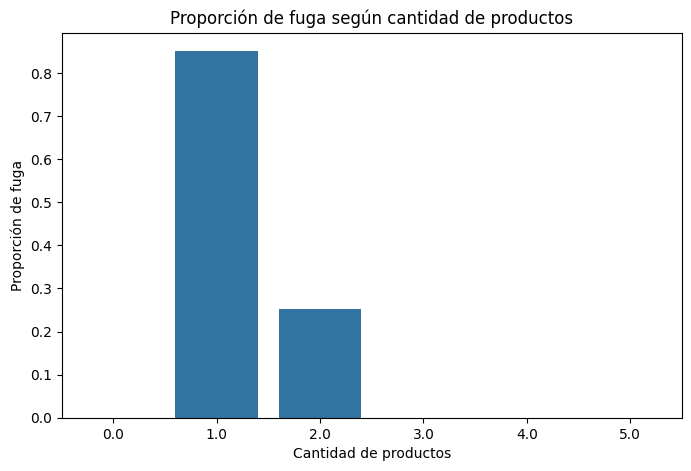

In [88]:
Fuga = df_juntos.groupby('Cant_Productos')['Fuga_Ultimo_Mes'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=Fuga, x='Cant_Productos', y='Fuga_Ultimo_Mes')
plt.title('Proporción de fuga según cantidad de productos')
plt.ylabel('Proporción de fuga')
plt.xlabel('Cantidad de productos')
plt.show()

In [99]:
Q1 = df_juntos['Ingreso_Mensual'].quantile(0.25)
Q3 = df_juntos['Ingreso_Mensual'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

print(f"Límite superior para el ingreso mensual: {limite_superior:.2f}")

outliers = df_juntos[df_juntos['Ingreso_Mensual'] > limite_superior]
print(f"\nNúmero de outliers detectados: {len(outliers)}")

Límite superior para el ingreso mensual: 8389399.01

Número de outliers detectados: 0


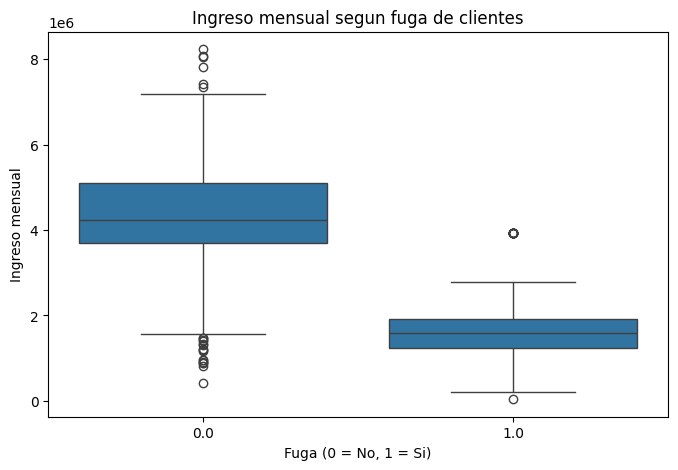

In [93]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_juntos, x='Fuga_Ultimo_Mes', y='Ingreso_Mensual')
plt.title('Ingreso mensual segun fuga de clientes')
plt.xlabel('Fuga (0 = No, 1 = Si)')
plt.ylabel('Ingreso mensual')
plt.show()

In [ ]:
# Lo que podemos observar en estas 2 gráficas es que es mas probable que haya una fuga si el cliente solamente tiene un solo producto

In [94]:
dummies = pd.get_dummies(df_juntos['Genero'], prefix='Genero', drop_first=True, dtype=int, dummy_na=True)
df_juntos = pd.concat([df_juntos, dummies], axis=1)
df_juntos.drop('Genero', axis=1, inplace=True)

print("DataFrame con One-Hot Encoding para 'Propósito':")
df_juntos.head()

DataFrame con One-Hot Encoding para 'Propósito':


,ID_Cliente,Edad,Ingreso_Mensual,Saldo_Cuenta,Cant_Productos,Fuga_Ultimo_Mes,Ingreso_Anual,Genero_Masculino,Genero_Otro,Genero_nan
0,1,46.033413,2.812419e+06,2058.469892,1.0,0.0,3.374903e+07,0,0,0
1,2,61.556330,8.323278e+05,2581.611324,1.0,1.0,9.987934e+06,0,1,0
2,3,48.472947,2.694336e+06,6285.609334,4.0,0.0,3.233203e+07,1,0,0
3,4,37.087825,5.412067e+06,16395.151188,4.0,0.0,6.494481e+07,0,0,0
4,5,39.298402,4.598928e+06,15631.855902,3.0,0.0,5.518713e+07,1,0,0


In [96]:
scaler = StandardScaler()

cols_to_scale = ['Ingreso_Mensual', 'Saldo_Cuenta']

scaled_cols = [col + '_scaled' for col in cols_to_scale]

df_juntos[scaled_cols] = scaler.fit_transform(df_juntos[cols_to_scale])

print("Media y Desv. Est. de las variables escaladas:")
print(df_juntos[scaled_cols].describe().loc[['mean', 'std']])

df_juntos[cols_to_scale + scaled_cols].head()

Media y Desv. Est. de las variables escaladas:
      Ingreso_Mensual_scaled  Saldo_Cuenta_scaled
mean            2.202682e-16        -1.065814e-17
std             1.000500e+00         1.000500e+00


,Ingreso_Mensual,Saldo_Cuenta,Ingreso_Mensual_scaled,Saldo_Cuenta_scaled
0,2.812419e+06,2058.469892,-0.597392,-0.542484
1,8.323278e+05,2581.611324,-1.874296,-0.467535
2,2.694336e+06,6285.609334,-0.673541,0.063122
3,5.412067e+06,16395.151188,1.079046,1.511478
4,4.598928e+06,15631.855902,0.554676,1.402124
